# 3.4 Climate Model Output from ESGF

```{note}
The code for downloading climate model data in this section was adapted from Section 6.1 of {cite:t}`anderson_narrative_2021`.
```

Up until now, this chapter has focused on acquiring and analyzing climate data from observations, or reanalysis data which assimilates observational data into a weather forecast model. These sources of data are only half of the story. Since this guide is about climate change projections, we must also learn how to download and process output from climate model simulations. 

Output from climate models that participated in the CMIP projects has been made publicly available for download from the [Earth System Grid Federation (ESGF)](https://esgf.llnl.gov/). The ESGF is a peer-to-peer network with nodes hosted by several research centres around the world. The archive of data hosted on a given node can be searched and navigated in a browser. The website for the node hosted at Lawrence Livermore National Laboratory in the USA can be found [at this link](https://esgf-dev1.llnl.gov/search), and links for all of the nodes can be found [here](https://esgf.llnl.gov/nodes.html). Via the browser interface, one can populate their data cart like an online store and generate a `wget` script that when executed, will download the selected data. However, this process can be somewhat cumbersome if you are interested in large amounts of data, or if you wish to create an automated workflow. For advanced users, the ESGF offers a RESTful API, which is outside the scope of this guide. In this guide, we will use the Python package ([esgf-pyclient](https://esgf-pyclient.readthedocs.io/en/latest/index.html)) (also called `pyesgf`) as an interface to the API. With `pyesgf`, one can either get an OPeNDAP URL to access the data directly or get a URL from which the data can be downloaded using the Python `requests` library.

[Complete documentation for the ESGF, and all options for accessing the data, can be found here](https://esgf.github.io/esgf-user-support/index.html).


As with the reanalysis and gridded observations, climate model output is typically very large in volume. For this reason, we will show examples in this notebook using monthly means instead of daily means or 6-hourly instantaneous output, which is typically required for climate impact analysis.

## 3.4.1 Searching For Data
To search the ESGF archive we must first establish a connection to an ESGF node using the `pyesgf.search.SearchConnection` class. To do this, we pass the URL for the node to `SearchConnection`. Since each node may only host a subset of the complete CMIP archive, the argument `distrib = True` tells the API to search across all nodes, not just the one we connected to.

```{note} 
There are sometimes network/service issues with the ESGF nodes, meaning you may sometimes get unexpected errors when using esgf-pyclient or when downloading data from the ESGF. You can try connecting to a different node, or waiting and trying to run the code later. The URLs for each of the nodes, and their operating status, can be found [on this page](https://esgf-node.llnl.gov/status/). If you're really stuck, you can try accessing CMIP data through Google Cloud Services, following the tutorial in [Section 3.5](section3.5_model_data_on_google_cloud.ipynb). Another option is to use the `intake-esm` Python package to access climate model output, which is the focus of [Section 3.6](section3.6_model_data_with_intake_esm.ipynb). These more modern options are easier to use, so it's ok if your main takeaway from this section is data analysis, starting at Section 3.4.3.
```


In [1]:
# import the required packages
from pyesgf.search import SearchConnection
import os
import glob
import requests
from tqdm import tqdm
import ec3

import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats as stats
from xclim import ensembles

# use this to suppress a warning which we can ignore
os.environ["ESGF_PYCLIENT_NO_FACETS_STAR_WARNING"] = "on"

In [ ]:
# establish a connection to the LLNL node
conn = SearchConnection('https://esgf-node.llnl.gov/esg-search', distrib=True)

# if that doesn't work, try the UK node
#conn = SearchConnection('https://esgf.ceda.ac.uk/esg-search', distrib=True)

# German Node:
#conn = SearchConnection('http://esgf-data.dkrz.de/esg-search', distrib=True)


After connecting to a node we need to decide which data we'd like to access. The search function takes a number of different search parameters (also called *facets*), listed and described in the table below. Unfortunately, the names for some of the search parameters are different for the CMIP5 and CMIP6 archives, so both are included in the table.

|                   Search Criterion                   |    CMIP5 Name    |         CMIP6 Name        |
|:----------------------------------------------------:|:----------------:|:-------------------------:|
|          Project (i.e. CMIP6, CORDEX, etc.)          |     `project`    |         `project`         |
|                      Model Name                      |      `model`     |        `source_id`        |
|                    Time Frequency                    | `time_frequency` | `table_id` or `frequency` |
|                   Forcing Scenario                   |   `experiment`   |      `experiment_id`      |
|                       Variable                       |    `variable`    |       `Variable ID`       |
|                    Ensemble Member                   |    `ensemble`    |        `member_id`        |
| Climate domain (i.e. atmosphere, ocean,  land, etc.) |      `realm`     |          `realm`          |


Note that the CMIP model variable names can be somewhat cryptic. You can find these using the drop-down menus on the left hand side of the [ESGF Metagrid page](https://esgf-dev1.llnl.gov/search), but for convenience, we link to a  table that maps the longer, more easily understandable variable names to the short variables names (which you include in the search), on [this page](https://clipc-services.ceda.ac.uk/dreq/mipVars.html).

To include multiple values for a search parameter (e.g. if you want data for both historical and SSP5-8.5 forcing scenarios), you can separate the search keywords with a comma (e.g. `experiment_id = 'historical,ssp585'`). Let's do exactly this, searching for `tas` (surface air temperature) data at monthly frequency from the model `CanESM5`, the Canadian model contributing to CMIP6. To limit the amount of data involved, we'll also select only one ensemble member (`r1i1p1f1`), instead of the whole ensemble. Dropping the search parameter `member_id` would make the search return results for all ensemble members (if there are multiple members for the model(s)/experiment(s) of interest).


In [3]:
query = conn.new_context(project="CMIP6",
                         experiment_id='historical,ssp585',
                         source_id = "CanESM5",
                         # monthly ('day' for daily, '6hr' for 6-hourly, etc.)
                         frequency = 'mon', 
                         member_id="r1i1p1f1",
                         variable_id = "tas")
results = query.search()

len(results)

19

Our search returned multiple results, meaning several different data files match our search criteria. The results still need a bit more processing until we can get the download URLs (or OPeNDAP URLs) for the data. Next, we'll do this processing, and make a `pd.DataFrame` mapping the file names to the URLs.



In [4]:
# sometimes running this cell raises an error about shards, but running it a second time seems to work.
files = []
for i in range(len(results)):
    try:
        hit = results[i].file_context().search()
    except:
        hit = results[i].file_context().search()
    files += list(map(lambda f: {'filename': f.filename, 
                                 'download_url': f.download_url, 
                                 'opendap_url': f.opendap_url}, hit))
files = pd.DataFrame.from_dict(files)
len(files)

28

We now have a longer list of files that match our search criteria. This might be a result of the distributed search returning the same data files, hosted on different nodes. Let's print out all of the file names to check for duplicates before we do any downloading.

In [5]:
for fname in files['filename'].sort_values(): # print in alphabetical order
    print(fname)

tas_Amon_CanESM5_historical_r1i1p1f1_gn_185001-201412.nc
tas_Amon_CanESM5_historical_r1i1p1f1_gn_185001-201412.nc
tas_Amon_CanESM5_historical_r1i1p1f1_gn_185001-201412.nc
tas_Amon_CanESM5_historical_r1i1p1f1_gn_185001-201412.nc
tas_Amon_CanESM5_historical_r1i1p1f1_gn_185001-201412.nc
tas_Amon_CanESM5_historical_r1i1p1f1_gn_185001-201412.nc
tas_Amon_CanESM5_historical_r1i1p1f1_gn_185001-201412.nc
tas_Amon_CanESM5_historical_r1i1p1f1_gn_185001-201412.nc
tas_Amon_CanESM5_ssp585_r1i1p1f1_gn_201501-210012.nc
tas_Amon_CanESM5_ssp585_r1i1p1f1_gn_201501-210012.nc
tas_Amon_CanESM5_ssp585_r1i1p1f1_gn_201501-210012.nc
tas_Amon_CanESM5_ssp585_r1i1p1f1_gn_201501-210012.nc
tas_Amon_CanESM5_ssp585_r1i1p1f1_gn_201501-210012.nc
tas_Amon_CanESM5_ssp585_r1i1p1f1_gn_201501-210012.nc
tas_Amon_CanESM5_ssp585_r1i1p1f1_gn_201501-210012.nc
tas_Amon_CanESM5_ssp585_r1i1p1f1_gn_201501-210012.nc
tas_Amon_CanESM5_ssp585_r1i1p1f1_gn_210101-218012.nc
tas_Amon_CanESM5_ssp585_r1i1p1f1_gn_210101-218012.nc
tas_Amon_CanES

As suspected, there are duplicates of each file - we really only want 4 files here. One for the historical experiment, and three for different time periods of the SSP5-8.5 experiment. 

In [6]:
# filter the DataFrame to drop duplicate filenames
files = files.drop_duplicates('filename')
files

,filename,download_url,opendap_url
0,tas_Amon_CanESM5_historical_r1i1p1f1_gn_185001...,https://esgf.ceda.ac.uk/thredds/fileServer/esg...,https://esgf.ceda.ac.uk/thredds/dodsC/esg_cmip...
1,tas_Amon_CanESM5_ssp585_r1i1p1f1_gn_201501-210...,https://esgf.ceda.ac.uk/thredds/fileServer/esg...,https://esgf.ceda.ac.uk/thredds/dodsC/esg_cmip...
2,tas_Amon_CanESM5_ssp585_r1i1p1f1_gn_210101-218...,https://esgf.ceda.ac.uk/thredds/fileServer/esg...,https://esgf.ceda.ac.uk/thredds/dodsC/esg_cmip...
3,tas_Amon_CanESM5_ssp585_r1i1p1f1_gn_218101-230...,https://esgf.ceda.ac.uk/thredds/fileServer/esg...,https://esgf.ceda.ac.uk/thredds/dodsC/esg_cmip...


## 3.4.2 Downloading Data

We are now ready to access the data, either directly with `xarray` and the OPenDAP URL or by downloading and saving the file locally. Since we already know how to do the former, we will do the latter. If you don't want to save the data in the current working directory, append filename to the path to the directory you'd like to write the data to using `os.path.join()`.

In [7]:
# Adapted from: https://stackoverflow.com/a/37573701
def download(url, filename):
    """
    Download a file hosted at <url> and write to <filename>
    """
    print("Downloading ", filename)
    r = requests.get(url, stream=True)
    total_size, block_size = int(r.headers.get('content-length', 0)), 1024
    with open(filename, 'wb') as f:
        for data in tqdm(r.iter_content(block_size),
                         total=total_size//block_size,
                         unit='KiB', unit_scale=True):
            f.write(data)

    if total_size != 0 and os.path.getsize(filename) != total_size:
        print("Downloaded size does not match expected size!\n",
              "FYI, the status code was ", r.status_code)

In [8]:
# create a directory (inside the current working directory) to save the data to
data_directory = "CanESM5_tas_monthly"
# only make the directory if it doesn't already exist
if not os.path.exists(data_directory): 
    os.mkdir(data_directory)


In [9]:
# download the data, one file at a time
for i in range(len(files)):
    url = files['download_url'].loc[i]
    filename = files['filename'].loc[i]
    path_to_write = os.path.join(data_directory, filename)
    
    # only download if the files doesn't already exist. 
    if not os.path.exists(path_to_write): 
        download(url, path_to_write)
    
# if there is an error downloading a file, you'll need to either delete the file,
# or change this block of code to call download(url, path_to_write) without 
# first checking if path_to_write exists,

Sometimes there are issues downloading files from the ESGF, due to technical errors on their end. One way to check whether the file was downloaded successfully is to look at the file size. For monthly data, we expect each file to be a few tens of MB, so if the file size is much smaller, there was likely a problem. This will get flagged in the `download` function we used to download the data, but we can also check the file size using the `os.stat` function, as demonstrated below:

In [10]:
# loop through each file, just like when we downloaded them
for i in range(len(files)):
    filename = files['filename'].loc[i]
    filepath = os.path.join(data_directory, filename)
    filestats = os.stat(filepath)
    size_in_MB = filestats.st_size / 1e6 # convert bytes to megabytes
    print(f"Size of {filename}: {size_in_MB} MB")

Size of tas_Amon_CanESM5_historical_r1i1p1f1_gn_185001-201412.nc: 52.443019 MB
Size of tas_Amon_CanESM5_ssp585_r1i1p1f1_gn_201501-210012.nc: 27.267498 MB
Size of tas_Amon_CanESM5_ssp585_r1i1p1f1_gn_210101-218012.nc: 25.23234 MB
Size of tas_Amon_CanESM5_ssp585_r1i1p1f1_gn_218101-230012.nc: 37.722355 MB


The size of each downloaded file is as expected, so we will proceed. If the rest of the notebook runs without error, then that's another sign that the download was successful.

## 3.4.3 Opening and Exploring the Data

Now that the files are downloaded and saved, we can open them directly with `xarray` and do some analysis. Let's plot a time series of temperature near Toronto for the whole record and compare the historical data to the Toronto City station observations (from Section 3.1). Since we're opening multiple files, each of which has data for a different period of time, we'll use the function `xr.open_mfdataset` ([documentation](https://docs.xarray.dev/en/stable/generated/xarray.open_mfdataset.html)) to open all of them at once, and automatically concatenate them along the time dimension. 

The wildcard character `*` fills any possible value for the position where it occurs. In the example below, it takes the place of both `historical` and `ssp585` in its first occurrence. In the second occurrence, it takes the place of the year range, e.g. `185001-201412` for the historical period, `201501-210012` for the first chunk of the SSP5-8.5 period, etc. The wildcard character is an example of a [regular expression](https://en.wikipedia.org/wiki/Regular_expression), which are symbols used to represent patterns in text.



In [11]:
# first open the CanESM5 data for ensemble member r1i1p1f1
ds_CanESM5 = xr.open_mfdataset(data_directory + "/tas_Amon_CanESM5_*_r1i1p1f1_gn_*.nc")

C:\Users\morga\AppData\Local\Temp\ipykernel_38952\1431313050.py:2: SerializationWarning: Unable to decode time axis into full numpy.datetime64[ns] objects, continuing using cftime.datetime objects instead, reason: dates out of range. To silence this warning use a coarser resolution 'time_unit' or specify 'use_cftime=True'.
  ds_CanESM5 = xr.open_mfdataset(data_directory + "/tas_Amon_CanESM5_*_r1i1p1f1_gn_*.nc")


In [12]:
# now get obs data - this function is copied and modified from Section 3.1
stn_ids_toronto_city = [5051, 31688, 41863]
df_list = []
for i, stn_id in enumerate(stn_ids_toronto_city):
    df = ec3.get_data(stn_id, 
                      type = 3, # monthly mean data
                      progress = False)
    if i > 0: # ensure no duplicate times
        df = df[df['Date/Time'] < df_list[i-1]['Date/Time'].min()]
    df_list.append(df)

df_obs = pd.concat(df_list, axis = 0)


column_name_dict = {'Date/Time': 'time', 
                    'Mean Temp (°C)': 'tas',
                    'Latitude (y)': 'lat',
                    'Longitude (x)': 'lon',
                    'Station Name': 'Name'}
    
df_obs = df_obs.rename(columns = column_name_dict)
df_obs = df_obs[list(column_name_dict.values())]
df_obs['time'] = pd.to_datetime(df_obs['time'])
df_obs = df_obs.set_index("time")
    
# sort the data in proper chronological order
df_obs = df_obs.sort_index()

# select data only up to 2015, when the "historical" simulation ends
df_obs = df_obs[df_obs.index.year.isin(range(1850, 2015))]

print(df_obs.index.min(), df_obs.index.max())

1850-01-01 00:00:00 2006-12-01 00:00:00


The monthly data for this station ends at the end of 2006, but we'll proceed regardless. Since we know that daily data is available up until the present, the best practice would be to calculate monthly means from the daily means (weighted by the number of days in the month), but we digress.

In [13]:
# interpolate the CanESM5 model data to the station location
station_lat = df_obs['lat'][0]
# add 360 since the model data longitudes go from (0, 360) instead of (-180, 180)
station_lon = df_obs['lon'][0] + 360 

tas_CanESM5 = ds_CanESM5.tas.interp(lat = station_lat, lon = station_lon) - 273.15

C:\Users\morga\AppData\Local\Temp\ipykernel_38952\2221172246.py:5: DeprecationWarning: cftime_range() is deprecated, please use xarray.date_range(..., use_cftime=True) instead.
  times_obs = xr.cftime_range(start = df_obs.index.min(),


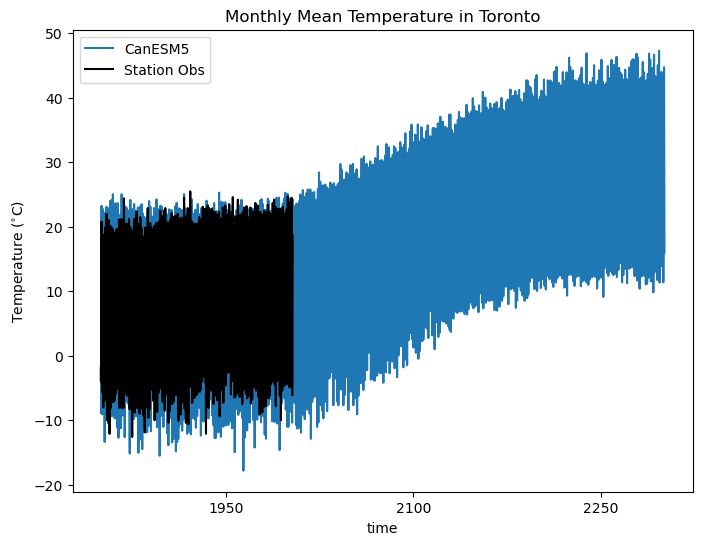

In [14]:
tas_CanESM5.load()

# station and model data have different time datatypes, so make a time axis with
# xarray to use for the obs
times_obs = xr.cftime_range(start = df_obs.index.min(), 
# need to add an extra month to the endpoint to make it closed at the right
                            end = df_obs.index.max() + pd.Timedelta(days=30), 
                            freq = 'M', calendar = 'noleap')
# plot the time series
fig, ax = plt.subplots(figsize = (8, 6))
tas_CanESM5.plot.line(ax = ax, label = 'CanESM5')
ax.plot(times_obs, df_obs['tas'], color = 'k', linestyle = '-', label = 'Station Obs')
ax.set_title("Monthly Mean Temperature in Toronto")
ax.set_ylabel(r"Temperature ($^{\circ}$C)")
plt.legend()
plt.show()

While we should not expect the individual months of the simulated data to match up with the station observations, the degree of overlap is encouraging that the model agrees decently well with observations. 

## 3.4.4 Basic Exploration of Model Bias

To better quantify this, we can plot the probability distribution of each dataset during their common period and calculate metrics such as the mean bias. Because the model has lower minima than the observations, we might expect it to be biased cold (i.e. negative mean bias). It also has slightly more maxima that exceed the observations, so perhaps it also has a higher standard deviation. Let's calculate these metrics and add them to the distribution plot.

In [15]:
# select model data during obs period
# add one to the max year so the range includes the max year
obs_year_range = range(times_obs.year.min(), times_obs.year.max() + 1) 
tas_CanESM5_obsperiod = tas_CanESM5.sel(time = tas_CanESM5.time.dt.year.isin(obs_year_range))

# fit Kernel Density Estimator so we can plot a smooth distribution
kde_CanESM5 = stats.gaussian_kde(tas_CanESM5_obsperiod.values)
# need to drop missing values or else scipy complains
kde_obs = stats.gaussian_kde(df_obs['tas'].dropna().values) 


# mean values for each dataset
tas_CanESM5_mean = tas_CanESM5_obsperiod.mean('time')
tas_obs_mean = df_obs['tas'].mean()

# stdevs for each dataset
tas_CanESM5_stdev = tas_CanESM5_obsperiod.std('time')
tas_obs_stdev = df_obs['tas'].std()

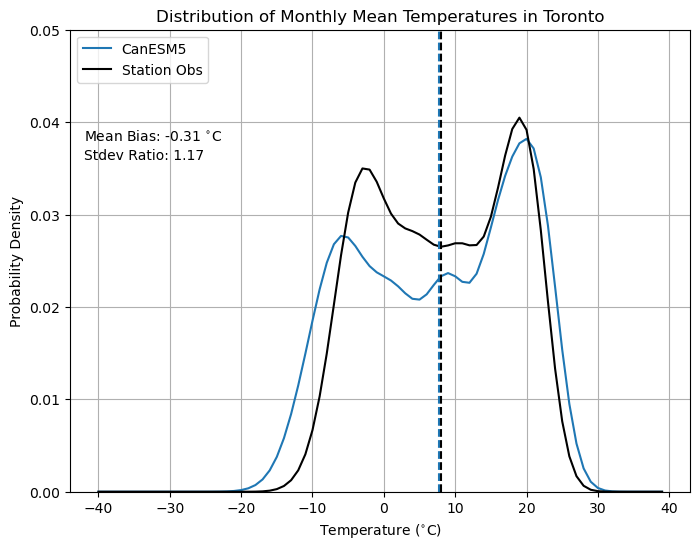

In [16]:
# range of temperatures to plot
temperatures = np.arange(-40, 40)
plt.figure(figsize = (8,6))
plt.title("Distribution of Monthly Mean Temperatures in Toronto")
plt.plot(temperatures, kde_CanESM5(temperatures), label = 'CanESM5')
plt.plot(temperatures, kde_obs(temperatures), label = 'Station Obs', color = 'k')
plt.vlines([tas_CanESM5_mean, tas_obs_mean], 0, 1,
           colors = ['tab:blue', 'k'], linestyles = '--')
plt.ylim(0, 0.05)
plt.xlabel(r"Temperature ($^{\circ}$C)")
plt.ylabel("Probability Density")
plt.legend(loc = 'upper left')
plt.grid()

# annotate with mean bias and ratio of stdevs
plt.text(-42, 0.038, r'Mean Bias: %.2f $^{\circ}$C' % (tas_CanESM5_mean - tas_obs_mean))
plt.text(-42, 0.036, r'Stdev Ratio: %.2f' % (tas_CanESM5_stdev / tas_obs_stdev))

plt.show()

Indeed, the model data for this location is biased slightly low, and has too high of a standard deviation, compared to the station observations. For sub-monthly data, these biases could possibly be worse, which is one reason why downscaling and bias-correction are necessary parts of climate impact analysis.

An interesting feature of these distributions of temperature is that they are *bimodal*, meaning there are two maxima. This is likely because of the seasonal cycle - the peak near lower temperatures is for cold-season months, and the other is for the warm season. For this reason, we often separate the data by month or by season when quantifying biases (at least for variables that have a strong seasonal cycle). Let's do this by comparing the monthly climatologies of the two datasets.

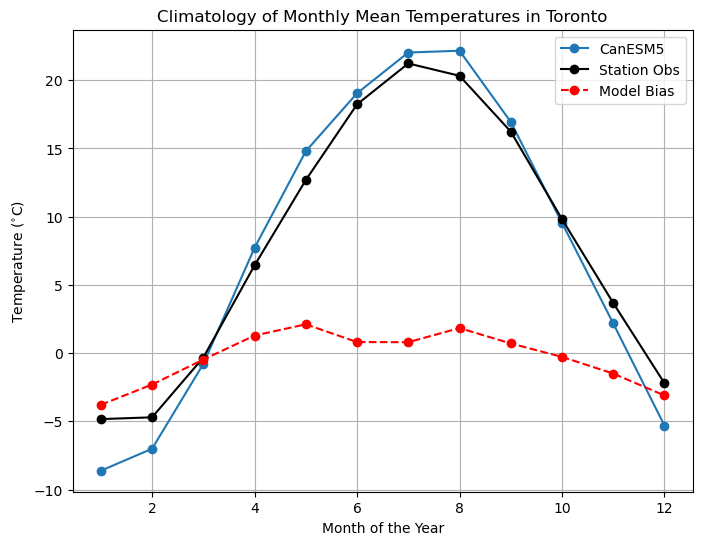

In [17]:
# calculate monthly climatologies
tas_monthlyclim_CanESM5 = tas_CanESM5_obsperiod.groupby('time.month').mean('time')
tas_monthlyclim_obs = df_obs['tas'].groupby(df_obs.index.month).mean()

# difference in climatologies
monthlyclim_bias = tas_monthlyclim_CanESM5.values - tas_monthlyclim_obs.values

months = tas_monthlyclim_CanESM5.month.values 

# plot
plt.figure(figsize = (8,6))
plt.title("Climatology of Monthly Mean Temperatures in Toronto")
plt.plot(months, tas_monthlyclim_CanESM5, label = 'CanESM5', marker = 'o')
plt.plot(months, tas_monthlyclim_obs, label = 'Station Obs', color = 'k', marker = 'o')
plt.plot(months, monthlyclim_bias, label = 'Model Bias', 
         color = 'red', linestyle = '--', marker = 'o')
plt.xlabel("Month of the Year")
plt.ylabel(r"Temperature ($^{\circ}$C)")
plt.legend()
plt.grid()
plt.show()

This plot is much more informative! The overall negative mean bias is due to the fact that the model's winter months are too cold, but in the annual mean this bias is somewhat washed out by the summer months being slightly too hot. This is also why the model data higher standard deviation than the observations - the contrast between the summer and winter seasons is greater than in observations. This example demonstrates that for variables with a strong seasonal cycle like temperature, bias correction should account for seasonally-varying biases. This can be done by grouping the data by the day or month of the year, and applying separate corrections to each of these groups. This example also illustrates why it's important to learn some basic climate science before working with climate data, and to do exploratory analysis with the observations and raw model data before doing bias correction or downscaling. If one lacked the required background knowledge or if they didn't assess the raw model biases and went directly to downscaling, they'd likely produce downscaled projections that still suffer from seasonally-dependent biases.

## 3.4.5 Significance Testing for Trends and Changes

When analyzing future climate projections, an important question to ask early in your study is whether your climate variables of interest show significant trends or changes over the time horizon you plan to study. If, for example, you are interested in using precipitation data to drive a hydrology model and investigate how flooding might change for a certain catchment under climate change, but the changes to precipitation in your study area are not statistically significant, then your impact study will likely also have a null result. 

### 3.4.5.1 Discrete Changes (Deltas)

There are a number of methods that climate scientists use to assess if climate change signals are significant. These methods range in complexity and statistical robustness. The simplest method would be to calculate the climatological standard deviation for the historical period and check if the projected mean change falls outside the one-sigma range. This method does not account for possible changes to the variance in the future period, the form of the distributions of the data (i.e. non-Gaussian variables like precipitation or wind speed), and is not very statistically robust. This extraordinarily simple method should only be used as a first rough assessment, and should not give much confidence that the changes are truly statistically significant.

The next best way to test if a mean change is statistically significant is the two sample Student's [$t$-test](https://en.wikipedia.org/wiki/Student%27s_t-test). This is a very common statistical test, used to assess if two different sets of data have different mean values. For large datasets, the [central limit theorem](https://en.wikipedia.org/wiki/Central_limit_theorem) tells us that the distribution of the sample mean tends towards a Gaussian distribution even for non-Gaussian variables, so we don't usually need to be concerned about the assumption of Gaussian distributions inherent to the $t$-test. However, we *do* need to be concerned about the assumption that each sample is *independent*. With time series data, especially climate time series data, there is nearly always significant serial dependence in the data. In other words, today's weather is strongly related to yesterday's weather, which means that data points close in time are not statistically independent of each other. For serially correlated data, the number of independent samples is not equal to the actual total number of samples. We instead calculate an *effective sample size* using the following formula {cite:p}`wilks_statistical_2019`:

$$N_{eff} = N \frac{1 - \rho_{1}}{1 + \rho_{1}} $$


Where $\rho_{1}$ is the *lag-one temporal autocorrelation* of the time series. For a time series $x(t)$ with time step $\Delta t$, this is the correlation between $x(t)$ and $x(t-\Delta t)$. 

Using the effective sample size correction, let's use the two sample Student's $t$-test to check if the monthly mean temperatures for Toronto in CanESM5 change significantly from the 1971-2000 period to the 2071-2100 period.

In [18]:
# select historical and future periods
tas_CanESM5_hist = tas_CanESM5.sel(time = tas_CanESM5.time.dt.year.isin(range(1971, 2001)))
tas_CanESM5_future = tas_CanESM5.sel(time = tas_CanESM5.time.dt.year.isin(range(2071, 2101)))


In [19]:
# calculate effective sample size for historical and future periods
def effective_sample_size(data):
    ntime = len(data.time)
    # times not including the final timestep
    times = data.time.isel(time = slice(0, ntime - 1))
    # data not including the first timestep
    data_lag = data.isel(time = slice(1, ntime))
    # match up time values, otherwise the xr.corr function won't return the correct output
    data_lag = data_lag.assign_coords(time = times)
    
    # calculate correlation
    autocor = xr.corr(data.sel(time = times),
                      data_lag,
                      dim = 'time')
    
    neff = ntime * (1 - autocor) / (1 + autocor)
    
    return neff

neff_hist = effective_sample_size(tas_CanESM5_hist)
neff_future = effective_sample_size(tas_CanESM5_future)

In [20]:
# calculate means and stdevs for each period
tas_CanESM5_hist_mean = tas_CanESM5_hist.mean('time')
tas_CanESM5_future_mean = tas_CanESM5_future.mean('time')

tas_CanESM5_hist_std = tas_CanESM5_hist.std('time')
tas_CanESM5_future_std = tas_CanESM5_future.std('time')

# perform two_sample t-test to see if future temperatures are higher than past
tstat, pval_neff = stats.ttest_ind_from_stats(tas_CanESM5_hist_mean,
                                              tas_CanESM5_hist_std,
                                              neff_hist,
                                              tas_CanESM5_future_mean, 
                                              tas_CanESM5_future_std, 
                                              neff_future,
                                              equal_var = False,
                                              alternative = 'less') 
# alt hypothesis is that the first dataset (historical) 
# has a lower mean than the second dataset (future)

# do it again using the total sample size, 
# to demonstrate how the p-value will be underestimated
tstat, pval_ntot = stats.ttest_ind_from_stats(tas_CanESM5_hist_mean,
                                              tas_CanESM5_hist_std,
                                              len(tas_CanESM5_hist.time),
                                              tas_CanESM5_future_mean, 
                                              tas_CanESM5_future_std, 
                                              len(tas_CanESM5_future.time),
                                              equal_var = False,
                                              alternative = 'less')

# print each p-value to 6 significant figures
print("Total Sample Size p-value: %.6f" % pval_ntot)
print("Effective Sample Size p-value: %.6f" % pval_neff)

Total Sample Size p-value: 0.000000
Effective Sample Size p-value: 0.001478


Comparing the p-values calculated using the total sample size and the effective sample size confirms that failing to account for serial dependence in the data leads to overconfidence in the significance of results. For this case, the mean change is still significant after accounting for serial dependence, but this may not always be true. If the lag-1 autocorrelation is big enough, or if the magnitude of the change is small enough, then failing to correct for the influence of serial dependence might lead you to mistake a null result for a significant one.

### 3.4.5.2 Trends

Sometimes a climate study might not focus on differences between a future and historical time period but instead focus on rates of change of a certain variable, i.e. a trend. Your first thought might be to use ordinary least squares to do a linear regression and test for significance of the slope parameter, but this will result in a similar issue to the one we just worked through. Ordinary linear regression assumes that all of the data samples are independent, so the presence of serial correlations will inflate the p-value. Additionally, many climate trends are nonlinear. Even global mean surface air temperature, possibly the most studied and well-understood climate variable, has been shown to have an accelerating trend over the past several decades {cite:p}`gulev_chapter_2023`. For these reasons, more robust statistical tests have been developed for testing the significance of trends of serially correlated climate data.

Here we will use the Mann-Kendall trend test {cite:p}`wilks_statistical_2019` to test the statistical signficance of the trend in monthly mean temperatures in Toronto, as simulated by CanESM5. Unfortunately, this test is not implemented in `scipy.stats`, but it is simple enough to code ourselves.

The Mann-Kendall test is a nonparametric test for the presence of a trend in a time series. The test statistic for this test is (from {cite:t}`yue_mann-kendall_2004`):

$$S = \sum_{i=1}^{N-1} \sum_{j=i+1}^{N} sgn(x_{j} - x_{i}) $$

Where $sgn(y)$ is $+1$ if $y$ is positive, $-1$ if $y$ is negative, and 0 if $y$ is exactly zero. $S$ is a count of how many pairs of data show increases over time minus the number that show decreases. For long enough time series (more than about 10 samples), $S$ is approximately Gaussian, and under the null hypothesis of no trend, $S$ should not be significantly different from zero. Wilks tells us that the variance of $S$ depends on how many of the $x_{i}$'s are unique. If there are no repeated values, then

$$
Var(S) = \frac{n(n-1)(2n+5)}{18}
$$

And if there are any ties (repeated values), then

$$
Var(S) = \frac{n(n-1)(2n+5) - \sum_{j=1}^{J}t_{j}(t_{j}-1)(2t_{j}+5)}{18}
$$

Where $J$ is the number of values that are repeated, and $t_{j}$ is the number of instances of the $j$'th non-unique value. Climate model data are floating point decimal numbers, so it is very rare to have two values that are exactly repeated, so we won't worry about this case here. If you are working with data that is only recorded to a finite tolerance (like for certain types of observational data), then you'll likely need to account for repeated values when calculating $S$ for the Mann-Kendall test. 

Conveniently, we can use the function `scipy.stats.kendaltau` to help us calculate $S$, since when there are no repeated values, $S = \frac{N(N-1)}{2}\tau$, where $\tau$ is the [Kendall rank correlation coefficient](https://en.wikipedia.org/wiki/Kendall_rank_correlation_coefficient). This statistic is  related to the Mann-Kendall test, sort of like how the Pearson correlation is related to ordinary linear regression. The issue with `scipy.stats.kendaltau` is that it will return a p-value that does not account for serial correlation, so we can't use it for hypothesis testing.

To account for the serial correlation, we can use the relationship between the sample size $N$ and the variance to define an effective variance:

$$
Var^{*}(S) = Var(S) \frac{1 + \rho_{1}}{1 - \rho_{1}}
$$

Having calculated our test statistic and its variance, and knowing that the sampling distribution of $S$ is Gaussian, we can convert $S$ to a standardized value $z$ that follows standard Gaussain distribution (i.e. a mean of zero and variance of 1). The conversion goes like:

$$
\begin{align*}
z = \left\{
        \begin{array}{ll}
            \frac{S-1}{\sqrt{Var^{*}(S)}} & \quad S \gt 0 \\
            \frac{S+1}{\sqrt{Var^{*}(S)}} & \quad S \lt 0
        \end{array}
    \right.
\end{align*}
$$

The p-value can then be calculated using the one-minus the CDF of a standard Gaussian (i.e. `scipy.stats.norm.sf`). Let's code this up and perform the Mann-Kendall test for the trend in our climate model data up to the year 2100.

In [21]:
def mann_kendall_pvalue(data):
    N = len(data.time)
    # kendall tau  - the np.arange(N) is there to represent
    # the monotonically increasing time axis
    tau = stats.kendalltau(data, np.arange(N))[0]
    
    # use tau to calculate the S statistic
    S = tau * N * (N-1) / 2

    # calculate the variance and effective variance,
    # taking advantage of our effective_sample_size function 
    # from the last example
    var_S = N * (N - 1) * (2*N + 5) / 18
    N_eff = effective_sample_size(data)
    correction_factor = N / N_eff
    var_S_eff = var_S * correction_factor
    
    # standardize S to a z-score
    z = (S - np.sign(S)) / np.sqrt(var_S_eff)
    
    # calculate one-sided p-value 
    # using the standard normal distribution
    pval = stats.norm.sf(z)
    
    return pval
    


In [22]:
pval_trend_mk = mann_kendall_pvalue(tas_CanESM5.sel(time = tas_CanESM5.time.dt.year <= 2100))
print("Mann-Kendall Test p-value for Trend: %.6f" % pval_trend_mk)

Mann-Kendall Test p-value for Trend: 0.000083


Since the p-value is very small for this robust test, we can confidently reject the null hypothesis of no trend and conclude that CanESM5 projects a significant increasing trend in Toronto monthly mean temperatures. When we move to looking at downscaled data from this model, we should expect to see results that are qualitatively similar, only with reduced biases relative to observations, and spatial information on a finer grid.

## 3.4.6 Analyzing Multiple Ensemble Members

The above examples used data only from a single ensemble member of CanESM5. In order to quantify uncertainty related to internal variability (Section 2.3), your final analysis should include multiple ensemble members, possibly from multiple models. Here we will use the Python module `xclim` and it's `xclim.ensembles` functionality to analyze data from multiple ensemble members at once. The documentation for these utilities is [here](https://xclim.readthedocs.io/en/latest/notebooks/ensembles.html).

```{admonition} Aside about xr.open_mfdataset

You can also use `xr.open_mfdataset` to open multiple files that represent different ensemble members. To do this, you'll need to use the keyword arguments it takes to intelligently structure the resulting Dataset. For example, you can use the argument `concat_dim` to create a new dimension called `'ensemble_member'`, so the data is shaped like `('ensemble_member', 'time', 'lat', 'lon')`. Unfortunately, this only works if all of the data files use the same calendar. If you have a multi-model ensemble with models that use different calendars, it's much better to use `xclim.ensembles`.

If you do it this way, it's tricky to concatenate along the time dimension as well (it's technically possible, but it requires advanced knowledge of `xclim.ensembles` and its calendar-handling features). The easiest way to handle different files for different time periods (like we did in 3.4.3) is to open the files for each time period separately, and then concatenate them using `xr.concat` ([documentation](https://docs.xarray.dev/en/stable/generated/xarray.concat.html)) and the keyword argument `dim = "time"`

Since file I/O is usually slow compared to other steps of analysis, it's best to do the smallest possible number of file opening calls. The best way to open your data will depend on the way your files are structured. Let's say that you have separate data files for each year for a 100-year period, and 10 ensemble members. In this situation, it would be better to iterate over the ensemble member (10 iterations) and concatenate over time with `open_mfdataset`, instead iterating of over the time period (100 iterations) and concatenating ensemble members with `xclim.ensembles`. You can combine the 10 datasets, each representing a different ensemble member, into a single Dataset using `xr.concat` and the keyword argument `dim = "ensemble_member"`, or create an `xclim.ensembles` by passing the list of datasets to `xclim.ensembles.create_ensemble`.

**Now back working with xclim.ensembles**
```

Below we'll download data for a few more ensemble members from CanESM5, plot the data for the different ensemble members, and calculate some ensemble statistics. To keep things simple, we'll do this only for the historical period.

```{caution}
It's commonly stated that ensemble or multi-model means give "better results" than data from individual ensemble members. This is true for certain cases - averaging model output for long-term mean quantities can reduce model biases, but you should *never* take an ensemble average as the first step in your workflow. Because different ensemble members have different realizations of internal variability and weather, averaging will attenuate variability and extremes. It's okay to calculate ensemble means and other statistics in your exploratory analysis, but downscaling should be done to individual ensemble members separately, and the range of final results be assessed as the range over the ensemble.
```

In [23]:
query2 = conn.new_context(project="CMIP6",
                         experiment_id='historical',
                         source_id = "CanESM5",
                         frequency = 'mon',
                         member_id="r2i1p1f1,r3i1p1f1,r4i1p1f1",
                         variable_id = "tas")
results2 = query2.search()
files2 = []
for i in range(len(results2)):
    try:
        hit = results2[i].file_context().search()
    except:
        hit = results2[i].file_context().search()
    files2 += list(map(lambda f: {'filename': f.filename, 
                                 'download_url': f.download_url, 
                                 'opendap_url': f.opendap_url}, hit))
files2 = pd.DataFrame.from_dict(files2)
files2 = files2.drop_duplicates('filename')

files2

,filename,download_url,opendap_url
0,tas_Amon_CanESM5_historical_r2i1p1f1_gn_185001...,https://esgf.ceda.ac.uk/thredds/fileServer/esg...,https://esgf.ceda.ac.uk/thredds/dodsC/esg_cmip...
1,tas_Amon_CanESM5_historical_r3i1p1f1_gn_185001...,https://esgf.ceda.ac.uk/thredds/fileServer/esg...,https://esgf.ceda.ac.uk/thredds/dodsC/esg_cmip...
2,tas_Amon_CanESM5_historical_r4i1p1f1_gn_185001...,https://esgf.ceda.ac.uk/thredds/fileServer/esg...,https://esgf.ceda.ac.uk/thredds/dodsC/esg_cmip...


In [24]:
# download the file
for i in range(len(files2)):
    url = files2['download_url'].loc[i]
    filename = files2['filename'].loc[i]
    path_to_write = os.path.join(data_directory, filename)
    
    # only download if the file doesn't already exist. 
    if not os.path.exists(path_to_write): 
        download(url, path_to_write)

In [25]:
# create a list of the files to create the ensemble, using the wildcard character *. 
# note that the order of the files is random when using glob.glob and the 
# wildcard character, so the order of the 'realization' dimension created by 
# xclim.ensembles.create_ensemble will also be random.
# You can specify the order of the 'realization' coordinates
# by making your own ordered list of file names.
historical_files = glob.glob(data_directory + "/tas_Amon_CanESM5_historical_*_gn_185001-201412.nc")

# open up the two historical files using xclim.ensembles
ds_ensemble = ensembles.create_ensemble(historical_files)

# Print a summary of the dataset.
# The dimension 'realization' represents the ensemble member
ds_ensemble

<xarray.Dataset> Size: 260MB
Dimensions:      (realization: 4, time: 1980, bnds: 2, lat: 64, lon: 128)
Coordinates:
  * time         (time) object 16kB 1850-01-16 12:00:00 ... 2014-12-16 12:00:00
  * lat          (lat) float64 512B -87.86 -85.1 -82.31 ... 82.31 85.1 87.86
  * lon          (lon) float64 1kB 0.0 2.812 5.625 8.438 ... 351.6 354.4 357.2
    height       float64 8B 2.0
  * realization  (realization) int32 16B 0 1 2 3
Dimensions without coordinates: bnds
Data variables:
    time_bnds    (realization, time, bnds) float64 127kB dask.array<chunksize=(1, 1980, 2), meta=np.ndarray>
    lat_bnds     (realization, lat, bnds) float64 4kB dask.array<chunksize=(1, 64, 2), meta=np.ndarray>
    lon_bnds     (realization, lon, bnds) float64 8kB dask.array<chunksize=(1, 128, 2), meta=np.ndarray>
    tas          (realization, time, lat, lon) float32 260MB dask.array<chunksize=(1, 1980, 64, 128), meta=np.ndarray>
Attributes: (12/53)
    CCCma_model_hash:            3dedf95315d603326fde4f5340dc0519d80d10c0
    CCCma_parent_runid:          rc3-pictrl
    CCCma_pycmor_hash:           33c30511acc319a98240633965a04ca99c26427e
    CCCma_runid:                 rc3.1-his01
    Conventions:                 CF-1.7 CMIP-6.2
    YMDH_branch_time_in_child:   1850:01:01:00
    ...                          ...
    tracking_id:                 hdl:21.14100/872062df-acae-499b-aa0f-9eaca76...
    variable_id:                 tas
    variant_label:               r1i1p1f1
    version:                     v20190429
    license:                     CMIP6 model data produced by The Government ...
    cmor_version:                3.4.0

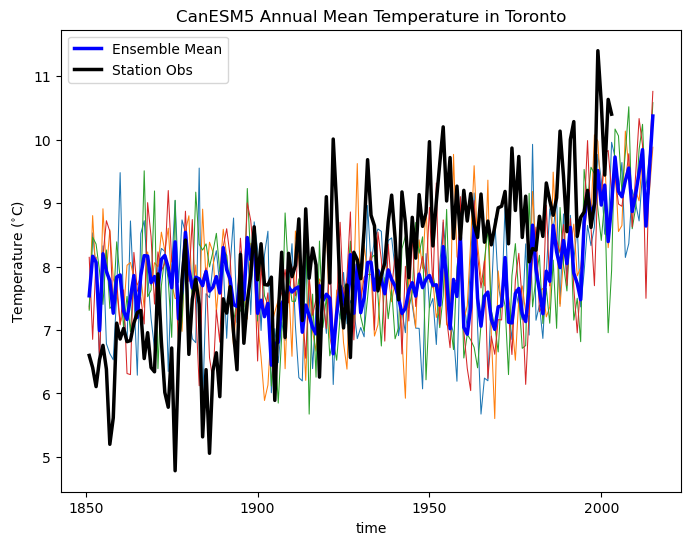

In [26]:
# interpolate the data to the Toronto station location
tas_CanESM5_ensemble = ds_ensemble.tas.interp(lat = station_lat, lon = station_lon) - 273.15

# calculate annual means - plotting monthly means is too noisy to see the example clearly
tas_CanESM5_ensemble_annual = tas_CanESM5_ensemble.resample(time = 'Y').mean()
tas_obs_annual = df_obs['tas'].resample('Y').mean()

# obs data is missing for a few years, and incomplete for 2003
tas_obs_annual = tas_obs_annual[tas_obs_annual.index.year < 2003]

# obs data year values to pass to plotting function
yrmax_obs = tas_obs_annual.index.year.max()
yrs_obs = tas_CanESM5_ensemble_annual.time.sel(time = tas_CanESM5_ensemble_annual.time.dt.year <= yrmax_obs)

# calculate ensemble mean to include in the plot
tas_CanESM5_annual_ensmean = tas_CanESM5_ensemble_annual.mean("realization")

# plot a time series of the annual mean temperatures for Toronto, using a different colour for each ensemble member
fig, ax = plt.subplots(figsize = (8, 6))
# ensemble mean
tas_CanESM5_annual_ensmean.plot.line(ax = ax, color = 'blue', 
                                     label = 'Ensemble Mean', 
                                     linewidth = 2.5, zorder = 2)

ax.plot(yrs_obs, tas_obs_annual, color = 'k', 
        label = 'Station Obs', linewidth = 2.5, zorder = 2)

tas_CanESM5_ensemble_annual.plot.line(ax = ax, hue = 'realization', 
                                      linewidth = 0.75,
                                      add_legend = False, 
                                      zorder = 1)

ax.set_title("CanESM5 Annual Mean Temperature in Toronto")
ax.set_ylabel(r"Temperature ($^{\circ}$C)")
ax.legend()
plt.show()


In the above plot, you can see how even the annual mean temperatures vary significantly across the ensemble, and show larger fluctuations than the ensemble mean (thick blue curve). The ensemble mean does not agree perfectly with the observations, because of model bias. Also, note that the year-to-year fluctuations in the ensemble mean are smaller than those for the observations. This is because observations reflect only one possible realization of the climate, so internal variability is still present. For observations, we can only disentangle forced trends (like the effects of increasing greenhouse gases) from internal variability using long-term trends. Over a short record, what might appear as a trend might actually be due to internal variability at decadal or interannual timescales. For model simulations, aggregating over multiple realizations smooths out the effects of internal variability and can give us a better estimate of the forced trend by itself. To get a plausible range of values, accounting for internal variability, you can use a measure of ensemble spread, like the standard deviation or range between a low and high quantile (e.g. 10th-90th percentile range).

## Summary

This notebook has worked through the process of downloading CMIP6 climate model data from the ESGF and doing some basic model validation using station observations. Any other data hosted on the ESGF, including CORDEX regional climate model data, can be accessed in the same way. Users are encouraged to navigate the ESGF web portal before using `pyesgf` to ensure you're using the correct facet names for the project you're searching, and that the search is returning the results you expect.